<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# Modelos de Árvore em Machine Learning

**Autor:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai)

Este notebook acompanha o artigo sobre modelos baseados em árvores: Árvore de Decisão, Random Forest e Gradient Boosting. Usamos o dataset Palmer Penguins para treinar e comparar os três algoritmos com `scikit-learn`.

## 1. Preparação dos Dados

O dataset Palmer Penguins reúne medidas corporais de 344 pinguins de três espécies (Adélie, Chinstrap e Gentoo). A tarefa é classificar a espécie a partir das medidas do animal.

In [1]:
# importar os pacotes necessários
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")

# carregar o dataset a partir do repositório do blog
url = "https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/datasets/penguins.csv"
df = pd.read_csv(url).dropna()

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


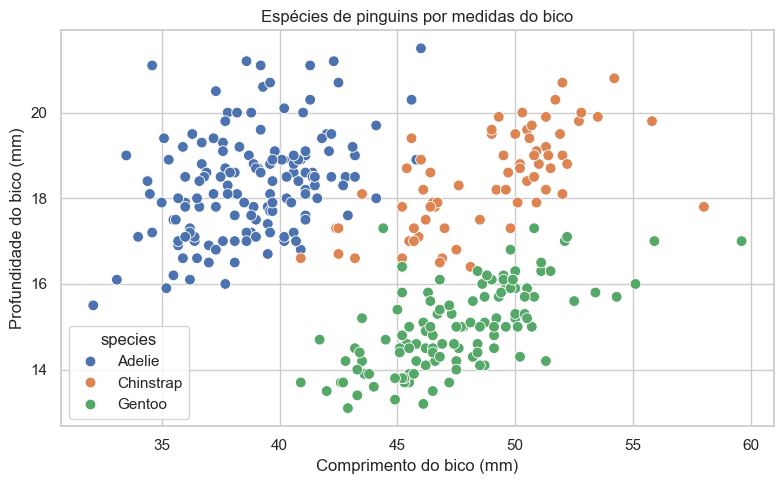

In [2]:
# visualizar a separação das espécies em duas dimensões
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm",
                hue="species", palette="deep", s=60, ax=ax)
ax.set_xlabel("Comprimento do bico (mm)")
ax.set_ylabel("Profundidade do bico (mm)")
ax.set_title("Espécies de pinguins por medidas do bico")
plt.tight_layout()
plt.show()

## 2. Árvore de Decisão

Separamos os dados em treino e teste e ajustamos uma Árvore de Decisão com profundidade máxima 3. A profundidade limitada mantém o modelo interpretável.

In [3]:
# selecionar as variáveis numéricas e o alvo
atributos = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = df[atributos]
y = df["species"]

# separar em conjuntos de treino (70%) e teste (30%)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# treinar a árvore de decisão com profundidade limitada
arvore = DecisionTreeClassifier(max_depth=3, random_state=42)
arvore.fit(X_treino, y_treino)

# avaliar a acurácia no conjunto de teste
acc_arvore = accuracy_score(y_teste, arvore.predict(X_teste))
print(f"Acurácia da Árvore de Decisão (teste): {acc_arvore:.4f}")

Acurácia da Árvore de Decisão (teste): 0.9400


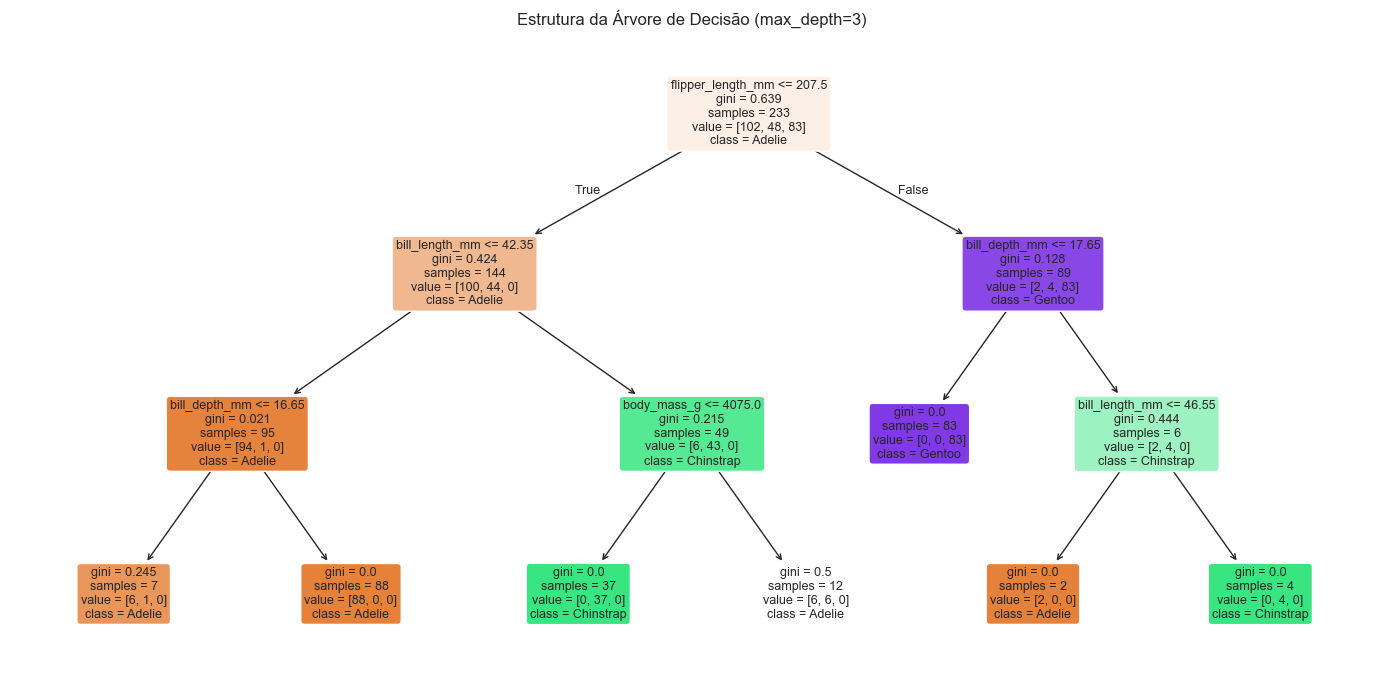

In [4]:
# visualizar a estrutura de decisão aprendida pela árvore
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(arvore, feature_names=atributos, class_names=arvore.classes_,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Estrutura da Árvore de Decisão (max_depth=3)")
plt.tight_layout()
plt.show()

## 3. O Limite de uma Árvore Única

Sem restrição de profundidade, a árvore memoriza o conjunto de treino. A diferença entre a acurácia de treino e de teste evidencia o sobreajuste (*overfitting*). Para visualizar as fronteiras de decisão em duas dimensões, treinamos os modelos apenas com as medidas do bico.

In [5]:
# treinar uma árvore sem limite de profundidade
arvore_profunda = DecisionTreeClassifier(random_state=42)
arvore_profunda.fit(X_treino, y_treino)

acc_treino = accuracy_score(y_treino, arvore_profunda.predict(X_treino))
acc_teste = accuracy_score(y_teste, arvore_profunda.predict(X_teste))

print(f"Acurácia no treino: {acc_treino:.4f}")
print(f"Acurácia no teste:  {acc_teste:.4f}")

Acurácia no treino: 1.0000
Acurácia no teste:  0.9500


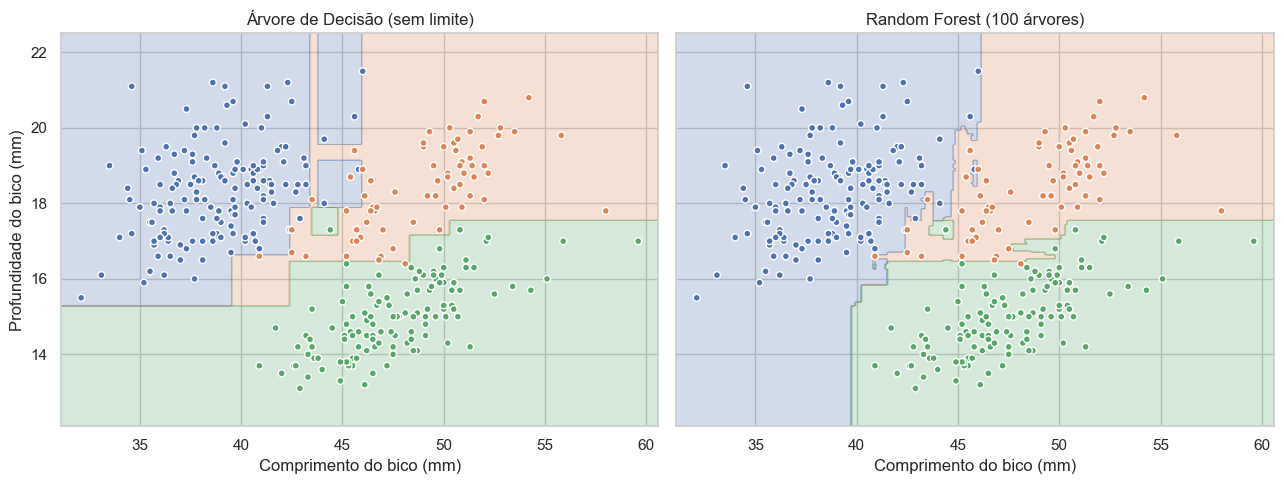

In [6]:
# comparar as fronteiras de decisão: árvore única vs. random forest
from matplotlib.colors import ListedColormap

atributos_2d = ["bill_length_mm", "bill_depth_mm"]
X2 = df[atributos_2d].values
y2 = df["species"].astype("category")
codigos = y2.cat.codes.values

X2_treino, X2_teste, c_treino, c_teste = train_test_split(
    X2, codigos, test_size=0.3, random_state=42, stratify=codigos)

modelos_2d = {
    "Árvore de Decisão (sem limite)": DecisionTreeClassifier(random_state=42),
    "Random Forest (100 árvores)": RandomForestClassifier(n_estimators=100, random_state=42),
}

# construir a grade de pontos para desenhar as regiões de decisão
xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - 1, X2[:, 0].max() + 1, 300),
    np.linspace(X2[:, 1].min() - 1, X2[:, 1].max() + 1, 300))

cores = ListedColormap(["#4C72B0", "#DD8452", "#55A868"])
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (nome, modelo) in zip(axes, modelos_2d.items()):
    modelo.fit(X2_treino, c_treino)
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cores)
    ax.scatter(X2[:, 0], X2[:, 1], c=codigos, cmap=cores, s=25, edgecolor="white")
    ax.set_title(nome)
    ax.set_xlabel("Comprimento do bico (mm)")

axes[0].set_ylabel("Profundidade do bico (mm)")
plt.tight_layout()
plt.show()

## 4. Random Forest

O Random Forest treina centenas de árvores em amostras diferentes dos dados (*bootstrap*) e combina as previsões por votação. O conjunto reduz a variância do modelo individual.

In [7]:
# treinar o random forest com 100 árvores
floresta = RandomForestClassifier(n_estimators=100, random_state=42)
floresta.fit(X_treino, y_treino)

acc_floresta = accuracy_score(y_teste, floresta.predict(X_teste))
print(f"Acurácia do Random Forest (teste): {acc_floresta:.4f}")

Acurácia do Random Forest (teste): 0.9700


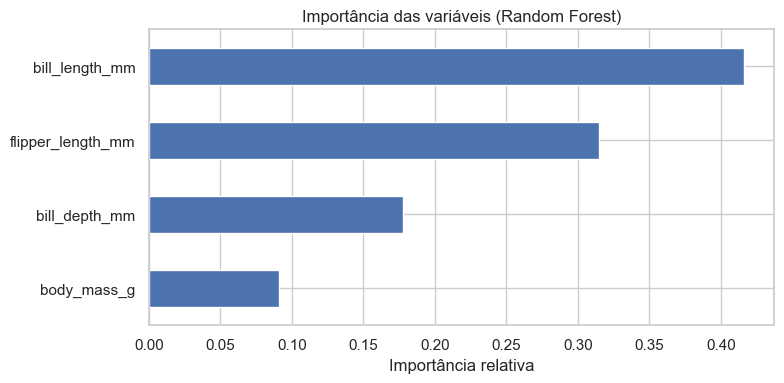

In [8]:
# medir a importância relativa de cada variável
importancias = pd.Series(floresta.feature_importances_, index=atributos)
importancias = importancias.sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
importancias.plot.barh(color="#4C72B0", ax=ax)
ax.set_xlabel("Importância relativa")
ax.set_title("Importância das variáveis (Random Forest)")
plt.tight_layout()
plt.show()

## 5. Gradient Boosting

No *boosting*, as árvores são treinadas em sequência: cada nova árvore corrige os erros residuais das anteriores. O resultado é um modelo aditivo, em geral mais preciso, porém mais sensível a hiperparâmetros.

In [9]:
# treinar o gradient boosting
boosting = GradientBoostingClassifier(n_estimators=100, random_state=42)
boosting.fit(X_treino, y_treino)

acc_boosting = accuracy_score(y_teste, boosting.predict(X_teste))
print(f"Acurácia do Gradient Boosting (teste): {acc_boosting:.4f}")

Acurácia do Gradient Boosting (teste): 0.9800


## 6. Comparação Final

Para uma comparação menos sensível à divisão treino/teste, avaliamos os três modelos com validação cruzada de 5 partições sobre o dataset completo.

In [10]:
# comparar os três modelos com validação cruzada (5 folds)
modelos = {
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}

resultados = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X, y, cv=5)
    resultados[nome] = scores
    print(f"{nome}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Árvore de Decisão: 0.9429 (+/- 0.0239)


Random Forest: 0.9790 (+/- 0.0154)


Gradient Boosting: 0.9760 (+/- 0.0153)


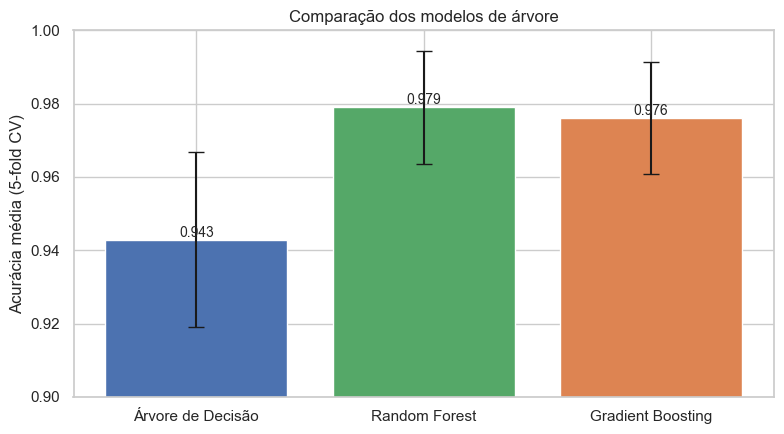

In [11]:
# visualizar a comparação entre os modelos
medias = [resultados[m].mean() for m in modelos]
desvios = [resultados[m].std() for m in modelos]

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(list(modelos.keys()), medias, yerr=desvios, capsize=6,
                color=["#4C72B0", "#55A868", "#DD8452"])
ax.set_ylim(0.9, 1.0)
ax.set_ylabel("Acurácia média (5-fold CV)")
ax.set_title("Comparação dos modelos de árvore")

for barra, media in zip(barras, medias):
    ax.annotate(f"{media:.3f}", (barra.get_x() + barra.get_width() / 2, media),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

---

A discussão completa de cada algoritmo está no artigo em [sigmoidal.ai](https://sigmoidal.ai). Para aprofundar em Machine Learning e Visão Computacional, acompanhe o blog e a newsletter do Sigmoidal.